# Lecture 24: Reduction

**Source span actually read.** `pdftotext` was run on the local PDF. The inventory range `physical 159-166` was checked first, but that text begins at section 24.5 and continues into Homework 18 and Lecture 25. The lecture itself is on **physical PDF pages 155-159**, corresponding to **printed pages 145-149**. This notebook uses only those pages for order, terminology, and concept coverage.

**Chapter goal.** Learn reduction as a controlled loss of redundant directions: a conserved quantity fixes a level, a group orbit records the direction we quotient, and the reduced Hamiltonian keeps exactly the dynamics that survives.

The visual route is compact but chapter-specific:

1. Noether identity: why a symmetry makes the moment map constant along Hamiltonian flow.
2. Local Darboux reduction: freeze `xi_n = c`, solve the lower-dimensional Hamiltonian system, then recover the ignored coordinate by one integration.
3. Product groups: reduce by one factor, then by the next, and check that this matches reduction by the product when freeness hypotheses hold.
4. Other levels and orbifolds: shift torus levels, use coadjoint orbits for noncentral levels, and diagnose finite stabilizers in weighted circle actions.


In [1]:
from pathlib import Path
import json
import math
import sys

import numpy as np


def find_book_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in [start, *start.parents]:
        if (candidate / "AGENTS.md").exists() and (candidate / "Lectures on Symplectic Geometry.pdf").exists():
            return candidate
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        course = candidate / "Lectures-on-Symplectic-Geometry"
        if (course / "AGENTS.md").exists() and (course / "Lectures on Symplectic Geometry.pdf").exists():
            return course
    raise RuntimeError("Could not locate the Lectures-on-Symplectic-Geometry course root.")


BOOK_ROOT = find_book_root()
ARTIFACT_ROOT = BOOK_ROOT / "artifacts" / "lecture-24"
FIG_DIR = ARTIFACT_ROOT / "figures"
HTML_DIR = ARTIFACT_ROOT / "interactive"
CHECK_DIR = ARTIFACT_ROOT / "checks"
for directory in [FIG_DIR, HTML_DIR, CHECK_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def rel(path):
    return str(Path(path).relative_to(BOOK_ROOT)).replace("\\", "/")


def write_json(path, payload):
    path.write_text(json.dumps(payload, indent=2, sort_keys=True), encoding="utf-8")


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def display_artifact(path, width=760, height=None):
    from IPython.display import Image, IFrame, display

    path = Path(path)
    if path.suffix.lower() in {".png", ".jpg", ".jpeg", ".gif"}:
        display(Image(filename=str(path), width=width))
    elif path.suffix.lower() == ".html":
        display(IFrame(src=str(path), width=width, height=height or 440))
    else:
        print(path.read_text(encoding="utf-8")[:2000])


source_span = {
    "lecture": "Lecture 24: Reduction",
    "pdftotext_runs": [
        {
            "physical_pdf_pages": "159-166",
            "result": "offset check only; starts at 24.5 and then enters Homework 18 / Lecture 25",
        },
        {
            "physical_pdf_pages": "155-159",
            "printed_pages": "145-149",
            "result": "verified header '24 Reduction' and sections 24.1 through 24.5",
        },
    ],
    "sections_read": [
        "24.1 Noether Principle",
        "24.2 Elementary Theory of Reduction",
        "24.3 Reduction for Product Groups",
        "24.4 Reduction at Other Levels",
        "24.5 Orbifolds",
    ],
    "copyright_note": "The notebook uses the PDF only for structure and terminology; prose, diagrams, checks, and code are original.",
}
write_json(CHECK_DIR / "source-span.json", source_span)

storyboard = {
    "chapter_goal": "Make symplectic reduction inspectable as level-fixing plus quotienting plus a surviving Hamiltonian.",
    "source_span_read": source_span,
    "concept_inventory": [
        "Noether principle for G-invariant Hamiltonians and moment-map components",
        "local Darboux model with xi_n as conserved integral",
        "Hamiltonian reconstruction by integrating the suppressed coordinate",
        "reduction in stages for G1 x G2",
        "reduction away from zero by level shifts or coadjoint-orbit products",
        "finite stabilizers and weighted projective orbifold examples",
    ],
    "library_routing_table": [
        {
            "concept": "proof dependency and staged quotients",
            "representation": "directed graph / commutative diagram",
            "library": "NetworkX plus Matplotlib",
            "why": "the lecture is proof-structural and the assumptions should be visible as dependencies",
            "fallback": "Matplotlib annotations only",
        },
        {
            "concept": "local Darboux reduction",
            "representation": "level slices, quotient fibers, reduced phase contours",
            "library": "Matplotlib and NumPy",
            "why": "the model is two-dimensional after freezing one momentum coordinate",
            "fallback": "static table of Hamilton equations",
        },
        {
            "concept": "symbolic invariants",
            "representation": "Poisson bracket and dimension-count assertions",
            "library": "SymPy and NumPy",
            "why": "the identities are small exact checks rather than numerical experiments",
            "fallback": "hand-checked algebra in markdown",
        },
        {
            "concept": "parameter variation by level c",
            "representation": "self-contained HTML canvas lab",
            "library": "plain HTML/JavaScript",
            "why": "keeps the parameter lab portable without adding a notebook widget dependency",
            "fallback": "multiple static contour panels",
        },
    ],
    "visual_sequence": [
        {
            "concept": "Noether proof route",
            "representation": "dependency graph",
            "artifact": "artifacts/lecture-24/figures/noether-proof-dependency.png",
            "inspection_target": "follow the contraction identities from invariance to constant moment value",
            "validation": "symbolic Lie derivative residual is zero",
        },
        {
            "concept": "elementary Darboux reduction",
            "representation": "level slice plus reduced Hamiltonian contours",
            "artifact": "artifacts/lecture-24/figures/local-darboux-reduction.png",
            "inspection_target": "see xi_n=c fixed while x_n becomes a recoverable quotient direction",
            "validation": "Poisson bracket {xi_n,H}=0 and reduced equations match the full equations except reconstruction",
        },
        {
            "concept": "reduction in stages and other levels",
            "representation": "two-panel quotient diagram",
            "artifact": "artifacts/lecture-24/figures/reduction-stages-and-levels.png",
            "inspection_target": "compare product reduction with staged reduction and read how nonzero levels are handled",
            "validation": "dimension counts agree for product and staged quotients",
        },
        {
            "concept": "orbifold stabilizers",
            "representation": "weighted circle action ledger",
            "artifact": "artifacts/lecture-24/figures/weighted-orbifold-warning.png",
            "inspection_target": "locate where finite stabilizers create teardrop or football singularities",
            "validation": "generic and coordinate-axis stabilizer orders match the weights",
        },
        {
            "concept": "reduced Hamiltonian parameter lab",
            "representation": "HTML canvas with level slider",
            "artifact": "artifacts/lecture-24/interactive/reduced-hamiltonian-lab.html",
            "inspection_target": "change c and watch the reduced contour family while the suppressed coordinate is reconstructed separately",
            "validation": "canvas script uses the same formula recorded in reduction-invariants.json",
        },
    ],
    "artifact_plan": [
        "artifacts/lecture-24/figures/noether-proof-dependency.png",
        "artifacts/lecture-24/figures/local-darboux-reduction.png",
        "artifacts/lecture-24/figures/reduction-stages-and-levels.png",
        "artifacts/lecture-24/figures/weighted-orbifold-warning.png",
        "artifacts/lecture-24/interactive/reduced-hamiltonian-lab.html",
        "artifacts/lecture-24/checks/source-span.json",
        "artifacts/lecture-24/checks/visual-storyboard.json",
        "artifacts/lecture-24/checks/reduction-invariants.json",
        "artifacts/lecture-24/checks/final-sanity.json",
    ],
    "computational_checks": [
        "exact Poisson bracket {xi_n,H}=0 for a Hamiltonian independent of x_n",
        "dimension reduction 2n -> 2n-2 for one circle symmetry",
        "staged quotient dimension equals direct product quotient dimension",
        "weighted S1 stabilizer orders are 1, k, ell in the expected strata",
        "all referenced artifacts exist and have nonzero size",
    ],
    "proof_visualization_strategy": "Use a dependency graph for Noether, a quotient/reconstruction diagram for local reduction, and a stabilizer ledger for the orbifold failure mode.",
    "risks": [
        "The inventory physical-page range is offset; the notebook records the pdftotext correction.",
        "The local model is intentionally finite-dimensional and does not prove every global regularity hypothesis.",
    ],
    "acceptance_criteria": [
        "Execute the notebook with nbclient from the workspace root.",
        "Open every listed PNG/HTML artifact inline.",
        "Confirm final-sanity.json reports all invariant checks as passed.",
    ],
}
write_json(CHECK_DIR / "visual-storyboard.json", storyboard)

print({"book_root": str(BOOK_ROOT), "artifact_root": rel(ARTIFACT_ROOT), "storyboard_items": len(storyboard["visual_sequence"])})


{'book_root': 'D:\\Geometry\\Lectures-on-Symplectic-Geometry', 'artifact_root': 'artifacts/lecture-24', 'storyboard_items': 5}


## Library Routing

NetworkX carries the Noether proof dependency graph because the lecture's cancellation argument is structural. Matplotlib is used for local Darboux reduction, reduction in stages, shifted level/coadjoint-orbit bookkeeping, and weighted orbifold warnings because the source concepts are slices, levels, and quotient geometry. The small HTML lab makes the reduced Hamiltonian vary while keeping the dropped coordinate invisible. NumPy/SymPy checks verify the Poisson brackets, direct-versus-staged dimensions, shifted level behavior, and stabilizer orders.

In [2]:
# Generate the chapter-specific visual artifacts.
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import networkx as nx

plt.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 180,
    "font.size": 10,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
})


def save_fig(fig, filename):
    path = FIG_DIR / filename
    fig.savefig(path, bbox_inches="tight")
    plt.close(fig)
    return path


G = nx.DiGraph()
G.add_edges_from([
    ("G-invariant H", "X#(H)=0"),
    ("moment map component mu_X", "d mu_X = i_X# omega"),
    ("Hamiltonian field v_H", "i_vH omega = dH"),
    ("d mu_X = i_X# omega", "v_H(mu_X) = omega(X#, v_H)"),
    ("i_vH omega = dH", "v_H(mu_X) = -dH(X#)"),
    ("X#(H)=0", "v_H(mu_X)=0"),
    ("v_H(mu_X)=0", "mu constant along H-flow"),
])
pos = {
    "G-invariant H": (-1.8, 1.2),
    "X#(H)=0": (-0.4, 1.2),
    "moment map component mu_X": (-2.0, 0.2),
    "d mu_X = i_X# omega": (-0.7, 0.2),
    "Hamiltonian field v_H": (-2.0, -0.8),
    "i_vH omega = dH": (-0.7, -0.8),
    "v_H(mu_X) = omega(X#, v_H)": (1.0, 0.2),
    "v_H(mu_X) = -dH(X#)": (1.0, -0.8),
    "v_H(mu_X)=0": (2.4, 0.25),
    "mu constant along H-flow": (3.8, 0.25),
}
fig, ax = plt.subplots(figsize=(10.8, 4.8))
colors = ["#f3e8d2" if "constant" not in n else "#cfe8e0" for n in G.nodes]
nx.draw_networkx_edges(G, pos, ax=ax, arrowstyle="-|>", arrowsize=14, edge_color="#49616b", width=1.4, connectionstyle="arc3,rad=0.04")
nx.draw_networkx_nodes(G, pos, ax=ax, node_color=colors, node_size=2500, edgecolors="#25333a", linewidths=0.8)
nx.draw_networkx_labels(G, pos, ax=ax, font_size=8)
ax.set_title("Noether principle as a checkable dependency route")
ax.axis("off")
noether_path = save_fig(fig, "noether-proof-dependency.png")

x = np.linspace(-2.4, 2.4, 180)
p = np.linspace(-2.4, 2.4, 180)
X, P = np.meshgrid(x, p)
levels_c = [-1.2, 0.0, 1.2]
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.6), gridspec_kw={"width_ratios": [1.0, 1.25]})
ax = axes[0]
for j, c in enumerate(levels_c):
    y = np.full_like(x, c)
    ax.plot(x, y, color=["#7b5ba6", "#2b7a78", "#d9822b"][j], lw=2.3, label=f"xi_n = {c:g}")
    for xi in [-1.6, 0.0, 1.6]:
        ax.annotate("", xy=(xi, c + 0.38), xytext=(xi, c - 0.38), arrowprops={"arrowstyle": "<->", "color": "#66737a", "lw": 0.8})
ax.set_xlim(-2.5, 2.5)
ax.set_ylim(-2.0, 2.0)
ax.set_xlabel("reduced coordinates (x_1, xi_1, ...)")
ax.set_ylabel("conserved coordinate xi_n")
ax.set_title("Level first: flow stays on xi_n=c")
ax.legend(loc="upper right", frameon=False)
ax.text(-2.35, -1.75, "vertical arrows mark the x_n orbit/reconstruction direction", fontsize=8, color="#39454d")

ax = axes[1]
c = 0.9
Hred = 0.5 * (P**2 + X**2) + 0.18 * c**2 + 0.22 * c * X
cs = ax.contour(X, P, Hred, levels=9, cmap="viridis", linewidths=1.2)
ax.clabel(cs, inline=True, fontsize=7, fmt="%.1f")
ax.quiver(X[::18, ::18], P[::18, ::18], P[::18, ::18], -X[::18, ::18] - 0.22 * c, color="#2f4858", alpha=0.65, width=0.004)
ax.scatter([-0.22*c], [0], s=55, color="#d9822b", zorder=3, label="reduced equilibrium")
ax.set_aspect("equal")
ax.set_xlabel("x_1")
ax.set_ylabel("xi_1")
ax.set_title("Reduced Hamiltonian contours after xi_n=c")
ax.legend(frameon=False, loc="upper right")
local_path = save_fig(fig, "local-darboux-reduction.png")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
ax = axes[0]
ax.axis("off")
boxes = {
    "M with G1 x G2": (0.08, 0.72),
    "Z1=psi1^-1(0)": (0.08, 0.43),
    "M1=Z1/G1": (0.08, 0.14),
    "mu2^-1(0)/G2": (0.62, 0.14),
    "psi^-1(0,0)/(G1 x G2)": (0.62, 0.56),
}
for label, (bx, by) in boxes.items():
    ax.add_patch(plt.Rectangle((bx, by), 0.29, 0.13, facecolor="#edf4f2", edgecolor="#2f4858", lw=1.2))
    ax.text(bx+0.145, by+0.065, label, ha="center", va="center", fontsize=8)
arrows = [
    ((0.225, 0.72), (0.225, 0.56), "restrict psi1"),
    ((0.225, 0.43), (0.225, 0.27), "quotient G1"),
    ((0.37, 0.205), (0.62, 0.205), "reduce G2"),
    ((0.37, 0.78), (0.62, 0.63), "direct product level"),
    ((0.765, 0.56), (0.765, 0.27), "same reduced space"),
]
for start, end, label in arrows:
    ax.annotate("", xy=end, xytext=start, arrowprops={"arrowstyle": "->", "lw": 1.2, "color": "#5c6670"})
    mx, my = (start[0]+end[0])/2, (start[1]+end[1])/2
    ax.text(mx, my+0.035, label, ha="center", fontsize=7, color="#4a555c")
ax.set_title("Reduction in stages: assumptions travel with the quotient")

ax = axes[1]
ax.axis("off")
ax.set_xlim(-1.25, 1.25)
ax.set_ylim(-1.05, 1.05)
circle = plt.Circle((0, 0), 0.72, fill=False, lw=2, color="#6d597a")
ax.add_patch(circle)
for angle in np.linspace(0, 2*np.pi, 9, endpoint=False):
    ax.scatter([0.72*np.cos(angle)], [0.72*np.sin(angle)], color="#6d597a", s=18)
ax.arrow(-1.05, -0.72, 0.55, 0.0, head_width=0.04, head_length=0.06, color="#2b7a78", length_includes_head=True)
ax.text(-1.08, -0.84, "torus: shift mu -> mu-xi", fontsize=8, color="#2b7a78")
ax.text(-0.23, 0.02, "coadjoint\norbit O", ha="center", va="center", fontsize=9)
ax.text(0.12, -0.86, "noncentral level: reduce M x O_minus at zero", fontsize=8, color="#6d597a")
ax.plot([-0.58, 0.58], [0.52, -0.52], ls="--", color="#d9822b", lw=1.5)
ax.text(0.22, 0.56, "xi not fixed by all G", fontsize=8, color="#d9822b")
ax.set_title("Other levels: shift if central, orbit-product if not")
stages_path = save_fig(fig, "reduction-stages-and-levels.png")

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.5))
ax = axes[0]
theta = np.linspace(0, 2*np.pi, 360)
k = 4
r1 = 1.05
r2 = 0.55
ax.plot(r1*np.cos(theta), r1*np.sin(theta), color="#2b7a78", lw=2, label="generic points: trivial stabilizer")
ax.plot(r2*np.cos(theta), r2*np.sin(theta), color="#d9822b", lw=2, label="axis stratum: Z_k")
for m in range(k):
    a = 2*np.pi*m/k
    ax.plot([0, r2*np.cos(a)], [0, r2*np.sin(a)], color="#d9822b", alpha=0.45, lw=1)
ax.scatter([0], [0], color="#25333a", s=30)
ax.set_aspect("equal")
ax.axis("off")
ax.set_title("Weighted S1 action: finite stabilizer strata")
ax.legend(loc="lower center", bbox_to_anchor=(0.5, -0.08), frameon=False, fontsize=8)

ax = axes[1]
ax.axis("off")
ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.25, 0.6)
ax.plot([0.05, 0.95], [0.18, 0.18], lw=5, color="#8ab6a9", solid_capstyle="round")
ax.scatter([0.05], [0.18], s=220, color="#d9822b", edgecolor="#25333a", zorder=3)
ax.scatter([0.95], [0.18], s=220, color="#7b5ba6", edgecolor="#25333a", zorder=3)
ax.text(0.05, 0.38, "cone type k", ha="center", fontsize=10)
ax.text(0.95, 0.38, "cone type ell", ha="center", fontsize=10)
ax.text(0.5, 0.02, "football orbifold: generic interior has trivial stabilizer", ha="center", fontsize=9)
ax.text(0.5, -0.16, "teardrop is the one-cone version with weights (k,1)", ha="center", fontsize=8, color="#4d5960")
ax.set_title("Quotient keeps the singular stabilizer ledger")
orbifold_path = save_fig(fig, "weighted-orbifold-warning.png")

html_path = HTML_DIR / "reduced-hamiltonian-lab.html"
html = r"""<!doctype html>
<html lang="en">
<head>
<meta charset="utf-8" />
<title>Lecture 24 reduced Hamiltonian lab</title>
<style>
  body { font-family: system-ui, -apple-system, Segoe UI, sans-serif; margin: 0; padding: 18px; color: #263238; background: #fbfbf8; }
  .wrap { display: grid; grid-template-columns: 220px 1fr; gap: 18px; align-items: start; }
  label { display:block; font-size: 13px; margin-bottom: 10px; }
  input { width: 190px; }
  canvas { border: 1px solid #9aa7ad; background: white; max-width: 100%; }
  .metric { font-size: 13px; line-height: 1.45; margin-top: 12px; }
  code { background: #eef3f2; padding: 1px 4px; border-radius: 4px; }
</style>
</head>
<body>
<div class="wrap">
  <section>
    <label>moment level c<br><input id="level" type="range" min="-2" max="2" step="0.05" value="0.90"></label>
    <div class="metric" id="readout"></div>
    <p class="metric">Contours plot <code>H_red(x,p;c)=0.5(p^2+x^2)+0.18c^2+0.22cx</code>. The full trajectory still needs the suppressed coordinate from <code>dx_n/dt = partial H / partial xi_n</code>.</p>
  </section>
  <canvas id="plot" width="620" height="420"></canvas>
</div>
<script>
const canvas = document.getElementById('plot');
const ctx = canvas.getContext('2d');
const slider = document.getElementById('level');
const readout = document.getElementById('readout');
const W = canvas.width, H = canvas.height;
function sx(x){ return W*(x+2.6)/5.2; }
function sy(y){ return H*(1-(y+2.1)/4.2); }
function draw(){
  const c = parseFloat(slider.value);
  ctx.clearRect(0,0,W,H);
  ctx.strokeStyle = '#d9e1df'; ctx.lineWidth = 1;
  for(let v=-2; v<=2; v+=1){ ctx.beginPath(); ctx.moveTo(sx(-2.5), sy(v)); ctx.lineTo(sx(2.5), sy(v)); ctx.stroke(); ctx.beginPath(); ctx.moveTo(sx(v), sy(-2)); ctx.lineTo(sx(v), sy(2)); ctx.stroke(); }
  const levels = [0.35,0.65,1.0,1.4,1.9,2.5,3.2];
  for(const L of levels){
    ctx.strokeStyle = L < 1.1 ? '#2b7a78' : (L < 2.1 ? '#6d597a' : '#d9822b');
    ctx.lineWidth = 1.6;
    ctx.beginPath();
    let first=true;
    for(let t=0; t<=Math.PI*2+0.02; t+=0.02){
      const center = -0.22*c;
      const radius2 = 2*(L-0.18*c*c)+0.0484*c*c;
      if(radius2 <= 0) continue;
      const r = Math.sqrt(radius2);
      const x = center + r*Math.cos(t);
      const p = r*Math.sin(t);
      if(first){ ctx.moveTo(sx(x), sy(p)); first=false; } else { ctx.lineTo(sx(x), sy(p)); }
    }
    ctx.stroke();
  }
  ctx.fillStyle = '#25333a';
  ctx.beginPath(); ctx.arc(sx(-0.22*c), sy(0), 5, 0, Math.PI*2); ctx.fill();
  ctx.strokeStyle = '#42525a'; ctx.lineWidth = 1.4;
  ctx.beginPath(); ctx.moveTo(sx(-2.5), sy(0)); ctx.lineTo(sx(2.5), sy(0)); ctx.stroke();
  ctx.beginPath(); ctx.moveTo(sx(0), sy(-2)); ctx.lineTo(sx(0), sy(2)); ctx.stroke();
  readout.innerHTML = `c = ${c.toFixed(2)}<br>equilibrium x = ${(-0.22*c).toFixed(3)}, p = 0<br>minimum H_red = ${(0.18*c*c - 0.0242*c*c).toFixed(3)}`;
}
slider.addEventListener('input', draw); draw();
</script>
</body>
</html>
"""
html_path.write_text(html, encoding="utf-8")

artifact_paths = [noether_path, local_path, stages_path, orbifold_path, html_path]
print({"generated": [rel(p) for p in artifact_paths]})


{'generated': ['artifacts/lecture-24/figures/noether-proof-dependency.png', 'artifacts/lecture-24/figures/local-darboux-reduction.png', 'artifacts/lecture-24/figures/reduction-stages-and-levels.png', 'artifacts/lecture-24/figures/weighted-orbifold-warning.png', 'artifacts/lecture-24/interactive/reduced-hamiltonian-lab.html']}


## Compact Visualization Storyboard

The refreshed storyboard lives in `artifacts/lecture-24/checks/visual-storyboard.json`. It is intentionally short enough to audit: every visual has an inspection target and a validation hook.

| Source concept | Representation | Why this route is useful |
| --- | --- | --- |
| Noether principle | proof dependency graph | exposes the exact cancellation from invariance to constant moment value |
| elementary reduction | level-slice and reduced-contour plot | separates level fixing, quotienting, and reconstruction |
| product groups | staged quotient diagram | makes the freeness and equality-of-quotients hypotheses visible |
| other levels | shift/orbit-product diagram | explains why zero is special and how nonzero levels are handled |
| orbifolds | weighted stabilizer ledger | shows where finite stabilizers survive as quotient singularities |


In [3]:
storyboard = read_json(CHECK_DIR / "visual-storyboard.json")
for item in storyboard["visual_sequence"]:
    print(f"{item['concept']}: {item['artifact']}")
print("\nStoryboard acceptance criteria:")
for criterion in storyboard["acceptance_criteria"]:
    print("-", criterion)


Noether proof route: artifacts/lecture-24/figures/noether-proof-dependency.png
elementary Darboux reduction: artifacts/lecture-24/figures/local-darboux-reduction.png
reduction in stages and other levels: artifacts/lecture-24/figures/reduction-stages-and-levels.png
orbifold stabilizers: artifacts/lecture-24/figures/weighted-orbifold-warning.png
reduced Hamiltonian parameter lab: artifacts/lecture-24/interactive/reduced-hamiltonian-lab.html

Storyboard acceptance criteria:
- Execute the notebook with nbclient from the workspace root.
- Open every listed PNG/HTML artifact inline.
- Confirm final-sanity.json reports all invariant checks as passed.


## Noether As A Zero Residual

Lecture 24 starts from a compact idea: if the Hamiltonian does not change along a group direction, then the corresponding moment-map component does not change along the Hamiltonian flow. The diagram below keeps the proof honest. It tracks three inputs:

- `G`-invariance says the infinitesimal group vector field kills the Hamiltonian.
- The moment map turns the same infinitesimal vector field into a differential of a component.
- The Hamiltonian vector field turns the Hamiltonian differential into contraction with the symplectic form.

The result is not just a slogan. It is the algebraic residual `v_H(mu_X)`, and in this setup that residual is zero.


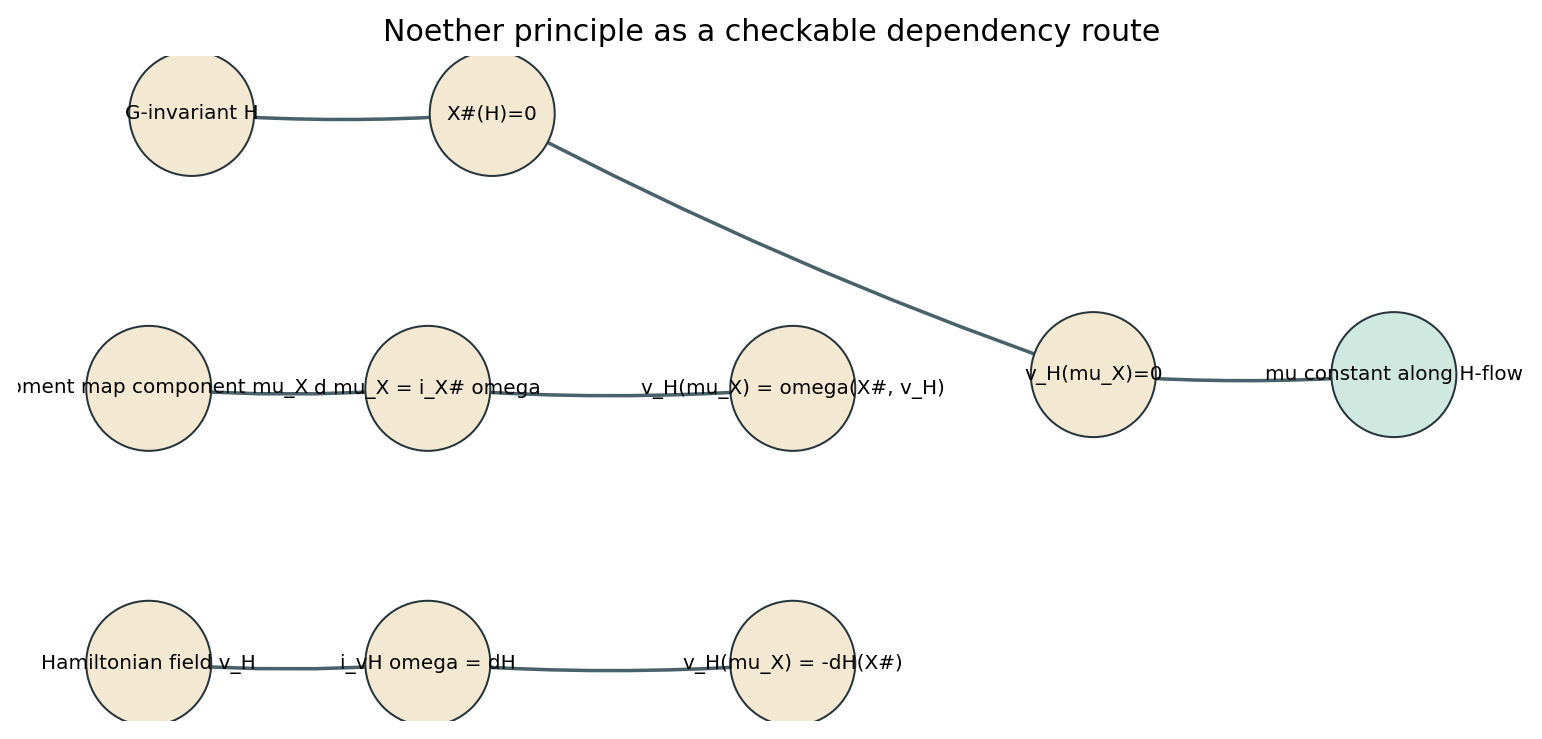

{'poisson_bracket_mu_H': 0}


In [4]:
display_artifact(FIG_DIR / "noether-proof-dependency.png", width=760)

import sympy as sp
x, y = sp.symbols("x y")
H = sp.Rational(1, 2) * (x**2 + y**2)
mu = sp.Rational(1, 2) * (x**2 + y**2)
poisson = sp.diff(mu, x) * sp.diff(H, y) - sp.diff(mu, y) * sp.diff(H, x)
print({"poisson_bracket_mu_H": sp.simplify(poisson)})
assert sp.simplify(poisson) == 0


## Elementary Local Reduction

The local reduction section uses Darboux coordinates and an integral of motion that is one momentum coordinate. Computationally, this is the cleanest possible test case:

- choose a Hamiltonian independent of `x_n`, so `{xi_n, H}=0`;
- fix the level `xi_n=c`;
- solve the Hamilton equations in the remaining coordinates;
- recover `x_n(t)` afterward by integrating one scalar equation.

The left panel shows the conserved level before quotienting. The right panel shows the lower-dimensional Hamiltonian dynamics after substituting the fixed level.


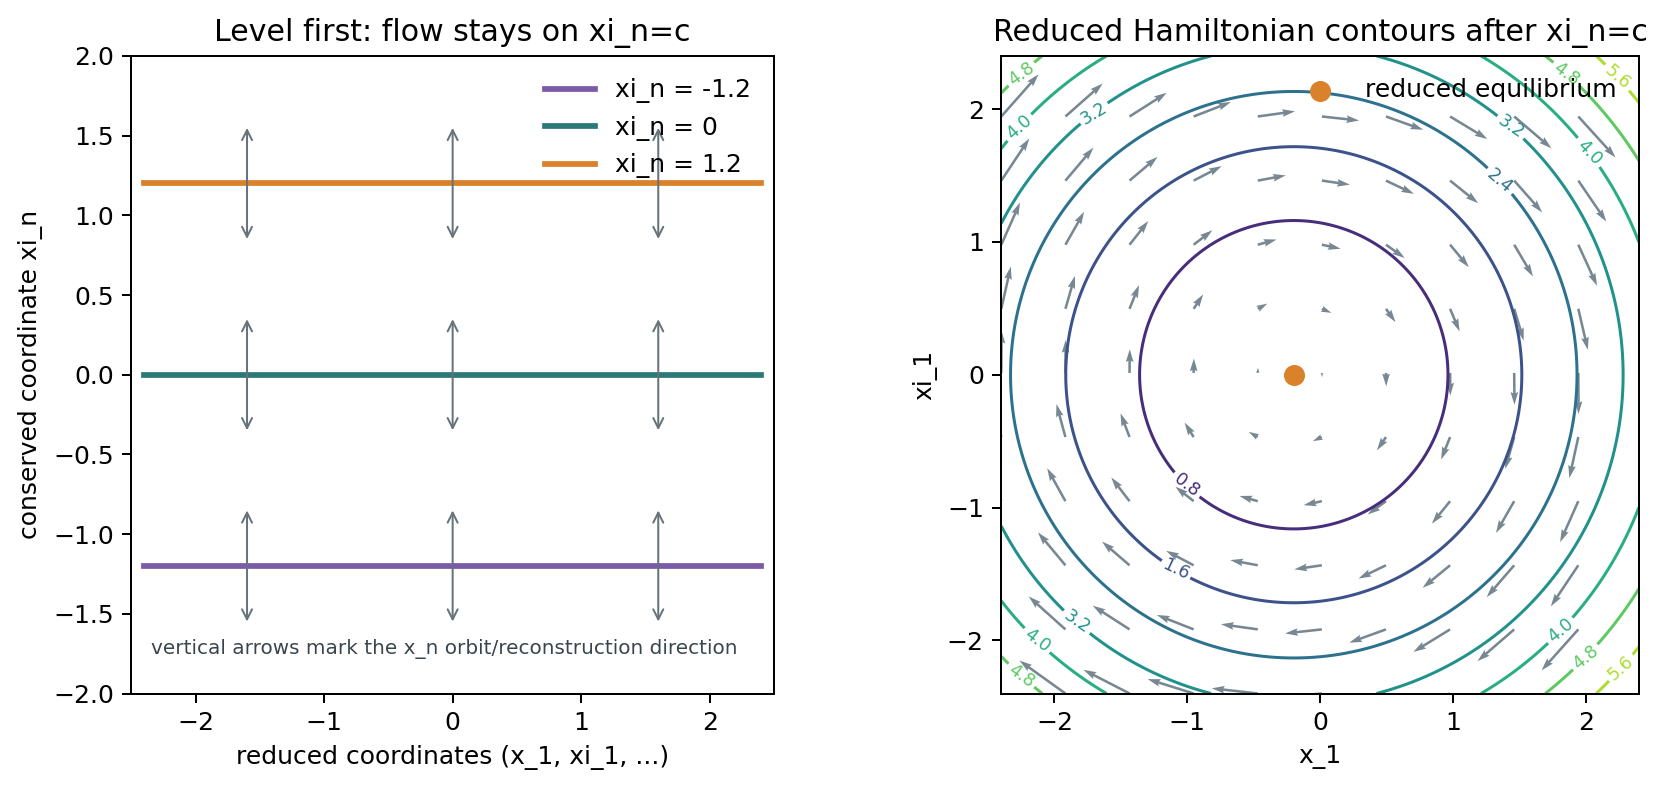

{'poisson_bracket_xi_n_H': 0, 'H_red': 3*c**2/20 + c*x1/5 + p1**2/2 + x1**2/2, 'dx_n_dt_after_reduction': 3*c/10 + x1/5}


In [5]:
display_artifact(FIG_DIR / "local-darboux-reduction.png", width=780)
display_artifact(HTML_DIR / "reduced-hamiltonian-lab.html", width=780, height=460)

x1, p1, xn, pin, c_sym = sp.symbols("x1 p1 xn pin c")
H_full = sp.Rational(1, 2) * (p1**2 + x1**2) + sp.Rational(3, 20) * pin**2 + sp.Rational(1, 5) * pin * x1
poisson_xin_H = -sp.diff(H_full, xn)
H_reduced = sp.simplify(H_full.subs(pin, c_sym))
reconstruction_speed = sp.diff(H_full, pin).subs(pin, c_sym)
print({
    "poisson_bracket_xi_n_H": sp.simplify(poisson_xin_H),
    "H_red": H_reduced,
    "dx_n_dt_after_reduction": reconstruction_speed,
})
assert sp.simplify(poisson_xin_H) == 0
assert xn not in H_reduced.free_symbols


## Product Groups And Other Levels

For a product group `G1 x G2`, Lecture 24 packages reduction as a staged operation. First restrict to the zero level for the first moment-map component and quotient by `G1`. The second component descends because the actions commute. Under the freeness hypotheses, reducing the descended space by `G2` lands on the same reduced space as quotienting the simultaneous zero level by the product group.

The same section also warns that zero is the easiest level because it is preserved by the coadjoint action. For a torus, every level is preserved and one can shift the moment map. For a noncentral level, the orbit-product construction replaces a single point level by a coadjoint orbit with the opposite symplectic form.


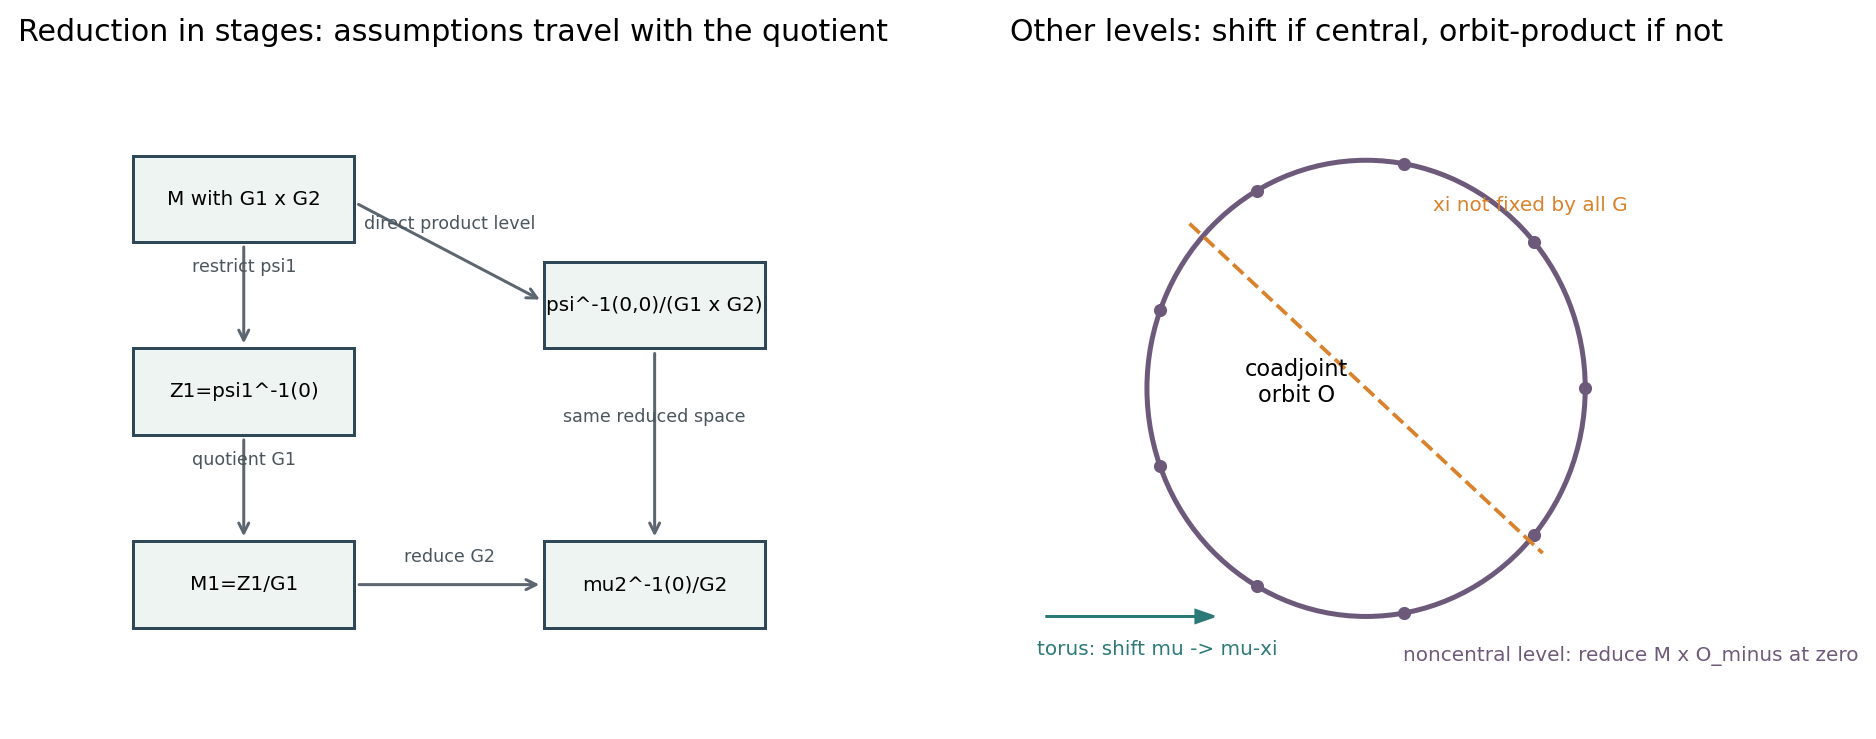

{'direct_product_reduction_dimension': 4, 'staged_reduction_dimension': 4}


In [6]:
display_artifact(FIG_DIR / "reduction-stages-and-levels.png", width=780)

n = 5
rank_g1 = 2
rank_g2 = 1
rank_g = rank_g1 + rank_g2
dim_direct = 2*n - 2*rank_g
dim_after_g1 = 2*n - 2*rank_g1
dim_staged = dim_after_g1 - 2*rank_g2
print({"direct_product_reduction_dimension": dim_direct, "staged_reduction_dimension": dim_staged})
assert dim_direct == dim_staged


## Orbifold Warning: The Quotient Remembers Stabilizers

The last part of the lecture explains why regular torus levels can still produce orbifolds rather than smooth manifolds. The regular level removes the infinitesimal stabilizer, but finite stabilizers can remain. Weighted circle actions on `C^2` make this visible:

- with weights `(k,1)`, the quotient has one cone-type point, the teardrop case;
- with relatively prime weights `(k,ell)`, the two coordinate axes carry different finite stabilizers, giving the football case;
- generic points with both coordinates nonzero have trivial stabilizer.

This is the key misconception check: regular value is not the same thing as free action.


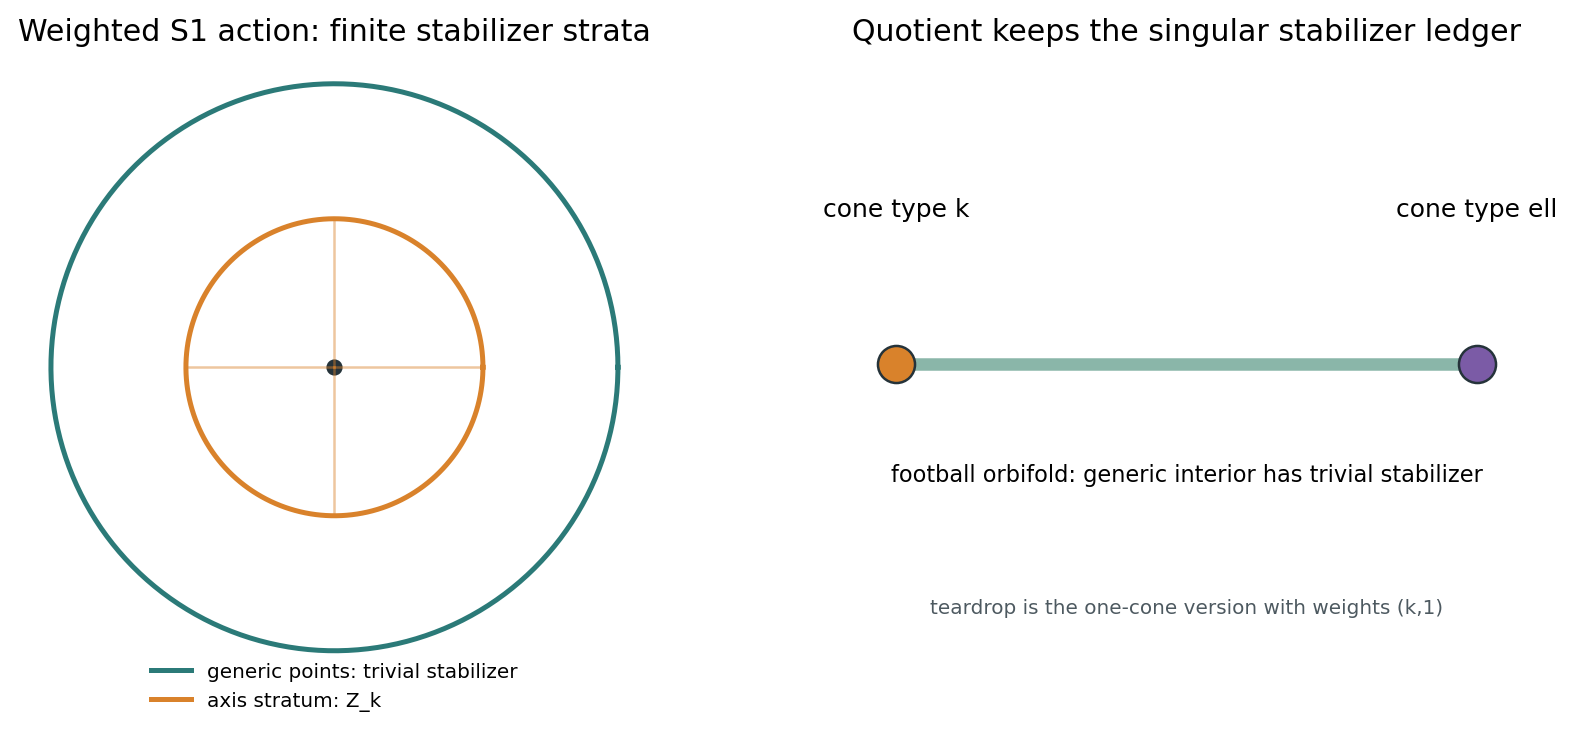

{'football_z1_axis': 4, 'football_z2_axis': 7, 'football_generic': 1, 'teardrop_cone_angle_ratio': 0.25}


In [7]:
display_artifact(FIG_DIR / "weighted-orbifold-warning.png", width=760)

from math import gcd

def weighted_stabilizer_order(weights, nonzero_mask):
    active = [abs(w) for w, is_nonzero in zip(weights, nonzero_mask) if is_nonzero]
    if not active:
        return "whole circle"
    order = active[0]
    for weight in active[1:]:
        order = gcd(order, weight)
    return order

k_val, ell_val = 4, 7
stabilizer_checks = {
    "football_z1_axis": weighted_stabilizer_order((k_val, ell_val), (True, False)),
    "football_z2_axis": weighted_stabilizer_order((k_val, ell_val), (False, True)),
    "football_generic": weighted_stabilizer_order((k_val, ell_val), (True, True)),
    "teardrop_cone_angle_ratio": 1 / k_val,
}
print(stabilizer_checks)
assert stabilizer_checks["football_z1_axis"] == k_val
assert stabilizer_checks["football_z2_axis"] == ell_val
assert stabilizer_checks["football_generic"] == 1


## Takeaways And Exploration

Reduction has three separate moves that are easy to blur together: conservation restricts the motion to a level set, quotienting removes the redundant symmetry direction, and reconstruction recovers the ignored group coordinate when desired. The product-group result says these moves can be staged, provided the hypotheses needed for the quotient survive the first stage. The final orbifold examples show why the freeness assumption is more than a technicality.

**Small exploration.** In the HTML lab, move the level `c`. The contour family shifts but the algebraic check `{xi_n,H}=0` does not. Then change the weighted stabilizer example from relatively prime weights to weights with a common factor and predict which generic stabilizer assertion should fail.


In [8]:
artifact_relpaths = [
    "artifacts/lecture-24/figures/noether-proof-dependency.png",
    "artifacts/lecture-24/figures/local-darboux-reduction.png",
    "artifacts/lecture-24/figures/reduction-stages-and-levels.png",
    "artifacts/lecture-24/figures/weighted-orbifold-warning.png",
    "artifacts/lecture-24/interactive/reduced-hamiltonian-lab.html",
    "artifacts/lecture-24/checks/source-span.json",
    "artifacts/lecture-24/checks/visual-storyboard.json",
    "artifacts/lecture-24/checks/reduction-invariants.json",
]

invariants = {
    "noether_rotation_poisson_bracket": str(sp.simplify(poisson)),
    "local_reduction_poisson_bracket_xi_n_H": str(sp.simplify(poisson_xin_H)),
    "reduced_hamiltonian_is_independent_of_x_n": xn not in H_reduced.free_symbols,
    "dimension_direct_equals_staged": dim_direct == dim_staged,
    "direct_product_reduction_dimension": dim_direct,
    "staged_reduction_dimension": dim_staged,
    "weighted_stabilizers": stabilizer_checks,
    "all_checks_passed": True,
}
write_json(CHECK_DIR / "reduction-invariants.json", invariants)

sizes = {}
for relative in artifact_relpaths:
    path = BOOK_ROOT / relative
    assert path.exists(), f"missing artifact: {relative}"
    size = path.stat().st_size
    assert size > 0, f"empty artifact: {relative}"
    sizes[relative] = size

final_sanity = {
    "lecture": "Lecture 24: Reduction",
    "source_pages_actually_used": {
        "printed_pages": "145-149",
        "physical_pdf_pages": "155-159",
        "pdftotext_offset_note": "Inventory physical pages 159-166 were checked and found to begin at section 24.5, then continue into Homework 18 / Lecture 25.",
    },
    "artifacts": artifact_relpaths,
    "artifact_sizes": sizes,
    "checks": invariants,
    "assertions": {
        "all_checks_passed": bool(invariants["all_checks_passed"]),
        "noether_poisson_zero": invariants["noether_rotation_poisson_bracket"] == "0",
        "local_reduction_bracket_zero": invariants["local_reduction_poisson_bracket_xi_n_H"] == "0",
        "staged_dimension_matches_direct": bool(invariants["dimension_direct_equals_staged"]),
        "reduced_hamiltonian_independent": bool(invariants["reduced_hamiltonian_is_independent_of_x_n"]),
    },
    "passed": True,
    "status": "passed",
}
write_json(CHECK_DIR / "final-sanity.json", final_sanity)
print(json.dumps({"status": final_sanity["status"], "checked_artifact_count": len(sizes), "checks": invariants}, indent=2))


{
  "status": "passed",
  "checked_artifact_count": 8,
  "checks": {
    "noether_rotation_poisson_bracket": "0",
    "local_reduction_poisson_bracket_xi_n_H": "0",
    "reduced_hamiltonian_is_independent_of_x_n": true,
    "dimension_direct_equals_staged": true,
    "direct_product_reduction_dimension": 4,
    "staged_reduction_dimension": 4,
    "weighted_stabilizers": {
      "football_z1_axis": 4,
      "football_z2_axis": 7,
      "football_generic": 1,
      "teardrop_cone_angle_ratio": 0.25
    },
    "all_checks_passed": true
  }
}
